In [1]:
!pip install xgboost joblib scikit-learn

In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)

from xgboost import XGBRegressor

pd.set_option("display.max_columns", None)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving feature_matrix.csv to feature_matrix.csv


In [80]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print(df.shape)

df.head()

(8170, 56)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,start_datetime,end_datetime,status,authenticated,modified_datetime,map_file,direction,description,veh_type,veh_no,corridor,priority,reason_breakdown,created_date,route_path,client_id,created_by_id,last_modified_by_id,assigned_to_police_id,comment,police_station,meta_data,kgid,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction,duration_minutes,hour_of_day,day_of_week,month,is_weekend,time_bucket,log_duration,planned_flag,lead_time_hours,event_cause_frequency,corridor_frequency,zone_frequency,is_peak_hour
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,0,2024-03-07 17:01:48.111000+00:00,NaN,closed,yes,2024-03-07 19:35:47.871698+00,NaN,NaN,s m circle in coming man track,lcv,FKN00GL0000,Tumkur Road,High,NaN,2024-03-07 17:03:51.164032+00:00,NaN,1,FKUSR00000,FKUSR00001,NaN,NaN,Peenya,NaN,FKKG000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,West Zone 1,NaN,NaN,17.0,3.0,3.0,0,daytime,NaN,0,0.0,4894,458.0,1196,0
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,0,2024-01-30 04:07:24.173000+00:00,NaN,resolved,yes,2024-01-30 04:17:46.828979+00,NaN,NaN,Starting problem,heavy_vehicle,FKN00GL0001,ORR East 1,High,NaN,2024-01-30 04:08:22.954979+00:00,NaN,1,FKUSR00002,FKUSR00001,NaN,NaN,HSR Layout,NaN,FKKG000001,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00:00,NaN,South Zone 2,NaN,NaN,4.0,1.0,1.0,0,early_morning,NaN,0,0.0,4894,244.0,805,1
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,0,2023-11-11 06:18:03.343000+00:00,NaN,closed,yes,2024-01-30 04:56:03.282003+00,NaN,NaN,ಊರ್ವಶಿ ಜಂಕ್ಷನ್ ನಲ್ಲಿ ಒಳಚರಂಡಿ ಚೇಂಬರ್ ಗೆ ಹೊಸದಾಗಿ...,NaN,NaN,Non-corridor,Low,NaN,2023-11-11 06:20:00.989398+00:00,NaN,1,FKUSR00003,FKUSR00001,NaN,NaN,Wilson Garden,NaN,FKKG000002,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00:00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction,115117.998975,6.0,5.0,11.0,1,early_morning,11.653722,0,0.0,637,3122.0,1492,1
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,1,2024-03-07 17:56:55.061000+00:00,NaN,closed,yes,2024-03-14 07:42:05.55005+00,NaN,NaN,tree fall,NaN,NaN,Non-corridor,Low,NaN,2024-03-07 17:58:56.696892+00:00,NaN,1,FKUSR00004,FKUSR00001,NaN,NaN,Sadashivanagar,NaN,FKKG000003,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.549440+00:00,NaN,NaN,NaN,West Zone 2,NaN,9465.174807,17.0,3.0,3.0,0,daytime,9.155480,0,0.0,284,3122.0,826,0
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,0,2024-01-30 04:56:32.348000+00:00,NaN,closed,yes,2024-01-30 05:35:17.33908+00,NaN,NaN,[LOCATION] ಪೈಪ್ [PERSON] ವಾಹನ ಆಫ್ ಆಗಿರುತ್ತದೆ ಸರ್,private_bus,FKN00GL0002,Non-corridor,Low,NaN,2024-01-30 04:58:55.937662+00:00,NaN,1,FKUSR00003,FKUSR00001,NaN,NaN,Wilson Garden,NaN,FKKG000002,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00:00,NaN,NaN,NaN,Central Zone 2,LalbaghMainGateJunc,38.749838,4.0,1.0,1.0,0,early_morning,3.682606,0,0.0,4894,3122.0,1492,1


In [81]:
df["start_datetime"] = pd.to_datetime(
    df["start_datetime"],
    errors="coerce",
    utc=True
)

In [82]:
df = df[
    df["duration_minutes"].notnull()
]

In [83]:
df = df[
    df["duration_minutes"] >= 0
]

In [84]:
print("Before Outlier Removal")

print(df["duration_minutes"].describe(
    percentiles=[0.90,0.95,0.99]
))

Before Outlier Removal
count      3126.000000
mean       6358.810074
std       20538.814630
min           0.696538
50%          64.526588
90%       17248.115202
95%       38926.422578
99%      109801.917111
max      201789.492498
Name: duration_minutes, dtype: float64


In [85]:
print("Before:", len(df))

df = df[
    df["duration_minutes"] <= 1440
].copy()

print("After:", len(df))

print(
    "Max Duration:",
    df["duration_minutes"].max()
)

Before: 3126
After: 2460
Max Duration: 1437.0530988


In [86]:
df["target_duration"] = np.log1p(
    df["duration_minutes"]
)

print(
    df["target_duration"]
    .describe()
)

count    2460.000000
mean        3.836687
std         1.131486
min         0.528590
25%         3.139848
50%         3.842395
75%         4.457240
max         7.271045
Name: target_duration, dtype: float64


In [87]:
print(df["target_duration"].head())

print(df["target_duration"].describe())

4     3.682606
18    5.684753
20    3.341049
25    6.738536
28    2.310531
Name: target_duration, dtype: float64
count    2460.000000
mean        3.836687
std         1.131486
min         0.528590
25%         3.139848
50%         3.842395
75%         4.457240
max         7.271045
Name: target_duration, dtype: float64


In [88]:
df["priority_encoded"] = (

    df["priority"]

    .astype(str)

    .str.strip()

    .str.lower()

    .map({

        "high":1,

        "low":0

    })

)

df["priority_encoded"] = (
    df["priority_encoded"]
    .fillna(0)
)

In [89]:
FEATURES = [

    "event_cause",

    "event_type",

    "corridor",

    "zone",

    "hour_of_day",

    "day_of_week",

    "requires_road_closure",

    "is_peak_hour",

    "planned_flag",

    "priority_encoded"

]

In [93]:
FEATURES = [
    col for col in FEATURES
    if col in df.columns
]

In [94]:
df = df.sort_values(
    "start_datetime"
)

In [95]:
split_index = int(
    len(df)*0.8
)

In [96]:
train_df = df.iloc[:split_index]

test_df = df.iloc[split_index:]

In [97]:
X_train = train_df[FEATURES]

X_test = test_df[FEATURES]

In [98]:
y_train = train_df[
    "target_duration"
]

y_test = test_df[
    "target_duration"
]

In [99]:
categorical_cols = [

    col for col in [

        "event_cause",

        "event_type",

        "corridor",

        "zone"

    ]

    if col in FEATURES

]

In [100]:
numeric_cols = [

    col for col in FEATURES

    if col not in categorical_cols

]

In [101]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "cat",

            OneHotEncoder(
                handle_unknown="ignore"
            ),

            categorical_cols

        ),

        (

            "num",

            "passthrough",

            numeric_cols

        )

    ]

)

In [102]:
regressor = XGBRegressor(

    n_estimators=500,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

In [ ]:
# Define RandomForestRegressor
rf_regressor = RandomForestRegressor(
    n_estimators=500, # Use a reasonable number of estimators
    max_depth=10, # Limit max depth to prevent overfitting
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Create a pipeline for Random Forest
rf_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        rf_regressor
    )
])

print("Fitting RandomForestRegressor...")
rf_pipeline.fit(X_train, y_train)
print("RandomForestRegressor training complete.")

In [ ]:
# Make predictions with Random Forest
rf_pred_log = rf_pipeline.predict(X_test)
rf_pred_minutes = np.expm1(rf_pred_log)

# Calculate metrics for Random Forest
rf_mae = mean_absolute_error(actual_minutes, rf_pred_minutes)
rf_median_error = median_absolute_error(actual_minutes, rf_pred_minutes)

print("\n--- RandomForestRegressor Metrics ---")
print(f"MAE (Random Forest): {rf_mae:.2f}")
print(f"Median Error (Random Forest): {rf_median_error:.2f}")

print("\n--- XGBoostRegressor Metrics (for comparison) ---")
print(f"MAE (XGBoost): {mae:.2f}")
print(f"Median Error (XGBoost): {median_error:.2f}")

In [103]:
pipeline = Pipeline([

    (
        "preprocessor",
        preprocessor
    ),

    (
        "model",
        regressor
    )

])

In [104]:
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['event_cause', 'event_type',
                                                   'corridor', 'zone']),
                                                 ('num', 'passthrough',
                                                  ['hour_of_day', 'day_of_week',
                                                   'requires_road_closure',
                                                   'is_peak_hour',
                                                   'planned_flag',
                                                   'priority_encoded'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=Non...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [105]:
pred_log = pipeline.predict(
    X_test
)

In [106]:
actual_minutes = np.expm1(
    y_test
)

In [107]:
pred_minutes = np.expm1(
    pred_log
)

In [108]:
mae = mean_absolute_error(
    actual_minutes,
    pred_minutes
)

print(
    "MAE:",
    round(mae,2)
)

MAE: 112.87


In [109]:
rmse = np.sqrt(

    mean_squared_error(
        actual_minutes,
        pred_minutes
    )

)

print(
    "RMSE:",
    round(rmse,2)
)

RMSE: 248.95


In [110]:
median_error = median_absolute_error(

    actual_minutes,

    pred_minutes

)

print(
    "Median Error:",
    round(median_error,2)
)

Median Error: 36.54


In [111]:
r2 = r2_score(

    actual_minutes,

    pred_minutes

)

print(
    "R²:",
    round(r2,4)
)

R²: 0.0051


In [112]:
with open(
    "duration_metrics.txt",
    "w"
) as f:

    f.write(
        f"MAE: {mae}\n"
    )

    f.write(
        f"RMSE: {rmse}\n"
    )

    f.write(
        f"Median Error: {median_error}\n"
    )

    f.write(
        f"R2: {r2}\n"
    )

In [113]:
sample_size = min(
    500,
    len(actual_minutes)
)

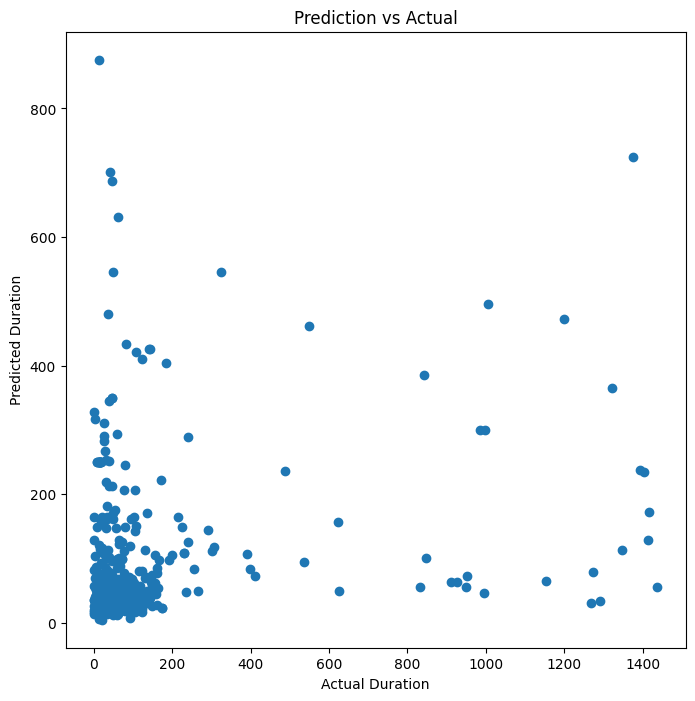

In [114]:
plt.figure(
    figsize=(8,8)
)

plt.scatter(

    actual_minutes[:sample_size],

    pred_minutes[:sample_size]

)

plt.xlabel(
    "Actual Duration"
)

plt.ylabel(
    "Predicted Duration"
)

plt.title(
    "Prediction vs Actual"
)

plt.savefig(
    "duration_prediction_vs_actual.png"
)

plt.show()

In [115]:
residuals = (

    actual_minutes

    -

    pred_minutes

)

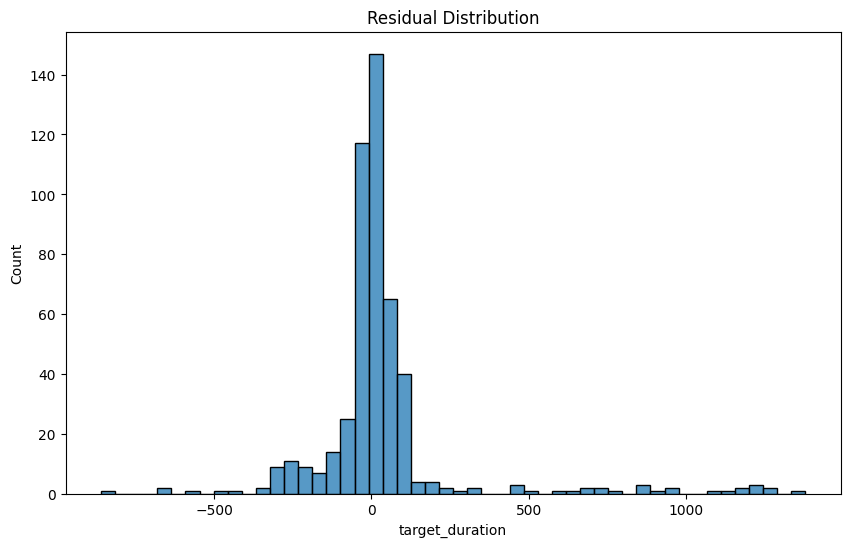

In [116]:
plt.figure(
    figsize=(10,6)
)

sns.histplot(
    residuals,
    bins=50
)

plt.title(
    "Residual Distribution"
)

plt.savefig(
    "residual_plot.png"
)

plt.show()

In [117]:
joblib.dump(

    pipeline,

    "duration_regressor.pkl"

)

['duration_regressor.pkl']

In [118]:
sample = X_test.iloc[[0]]

sample

,event_cause,event_type,corridor,zone,hour_of_day,day_of_week,requires_road_closure,is_peak_hour,planned_flag,priority_encoded
1520,tree_fall,unplanned,Non-corridor,North Zone 2,20.0,4.0,0,1,0,0


In [119]:
pred = pipeline.predict(
    sample
)

np.expm1(pred)

array([46.1257], dtype=float32)

In [120]:
print("MAE:", mae)
print("RMSE:", rmse)
print("Median Error:", median_error)
print("R2:", r2)

print(actual_minutes.describe())

MAE: 112.86944250657177
RMSE: 248.95243452280585
Median Error: 36.54245711800942
R2: 0.005141767035400591
count     492.000000
mean      119.690973
std       249.848982
min         0.696538
25%        21.908996
50%        46.838804
75%        93.633488
max      1437.053099
Name: target_duration, dtype: float64


In [121]:
print(df["duration_minutes"].describe())

count    2460.000000
mean       98.979719
std       206.431908
min         0.696538
25%        22.100364
50%        45.637056
75%        85.249147
max      1437.053099
Name: duration_minutes, dtype: float64
